In [3]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Отключаем предупреждения для чистоты вывода
warnings.filterwarnings('ignore')

# Настройка стиля графиков seaborn
sns.set(style="whitegrid")


# Загрузка данных
data = pd.read_csv('V8_classification_lr3.csv')

# Выводим первые 5 строк для первичного ознакомления с данными
display(data.head())

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [7]:
# a. Ознакомление с данными с помощью описательной статистики
print("Информация о наборе данных:")
display(data.info())

Информация о наборе данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       4601 non-null   float64
 1   1       4601 non-null   float64
 2   2       4601 non-null   float64
 3   3       4601 non-null   float64
 4   4       4601 non-null   float64
 5   5       4601 non-null   float64
 6   6       4601 non-null   float64
 7   7       4601 non-null   float64
 8   8       4601 non-null   float64
 9   9       4601 non-null   float64
 10  10      4601 non-null   float64
 11  11      4601 non-null   float64
 12  12      4601 non-null   float64
 13  13      4601 non-null   float64
 14  14      4601 non-null   float64
 15  15      4601 non-null   float64
 16  16      4601 non-null   float64
 17  17      4601 non-null   float64
 18  18      4601 non-null   float64
 19  19      4601 non-null   float64
 20  20      4601 non-null   float64
 21  21      4

None

In [9]:
print("\nОписательная статистика числовых признаков:")
display(data.describe())


Описательная статистика числовых признаков:


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,Class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


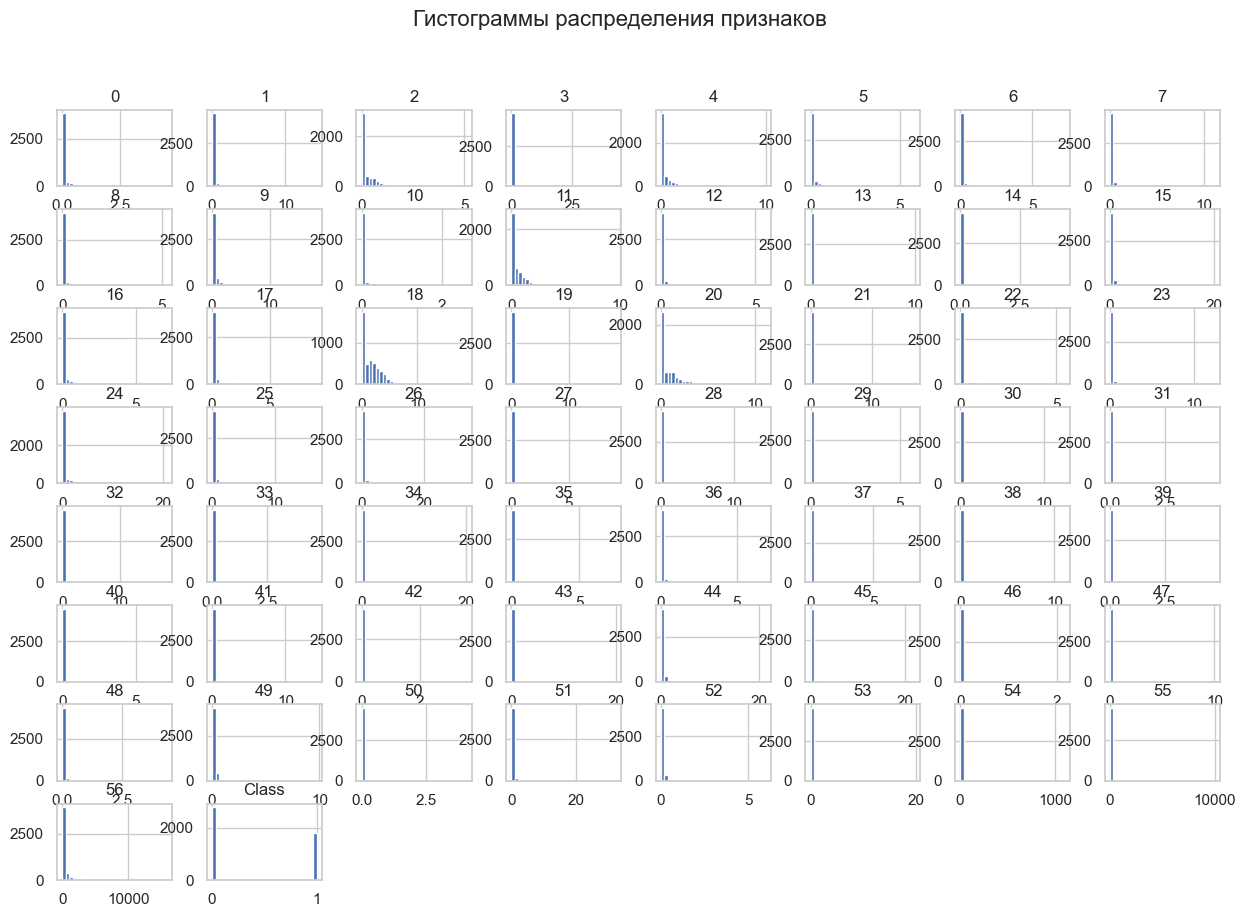

In [15]:
# b. Визуализация данных

# 1. Одномерная визуализация: построим гистограммы для каждого числового признака
data.hist(bins=30, figsize=(15, 10))
plt.suptitle("Гистограммы распределения признаков", fontsize=16)
plt.show()

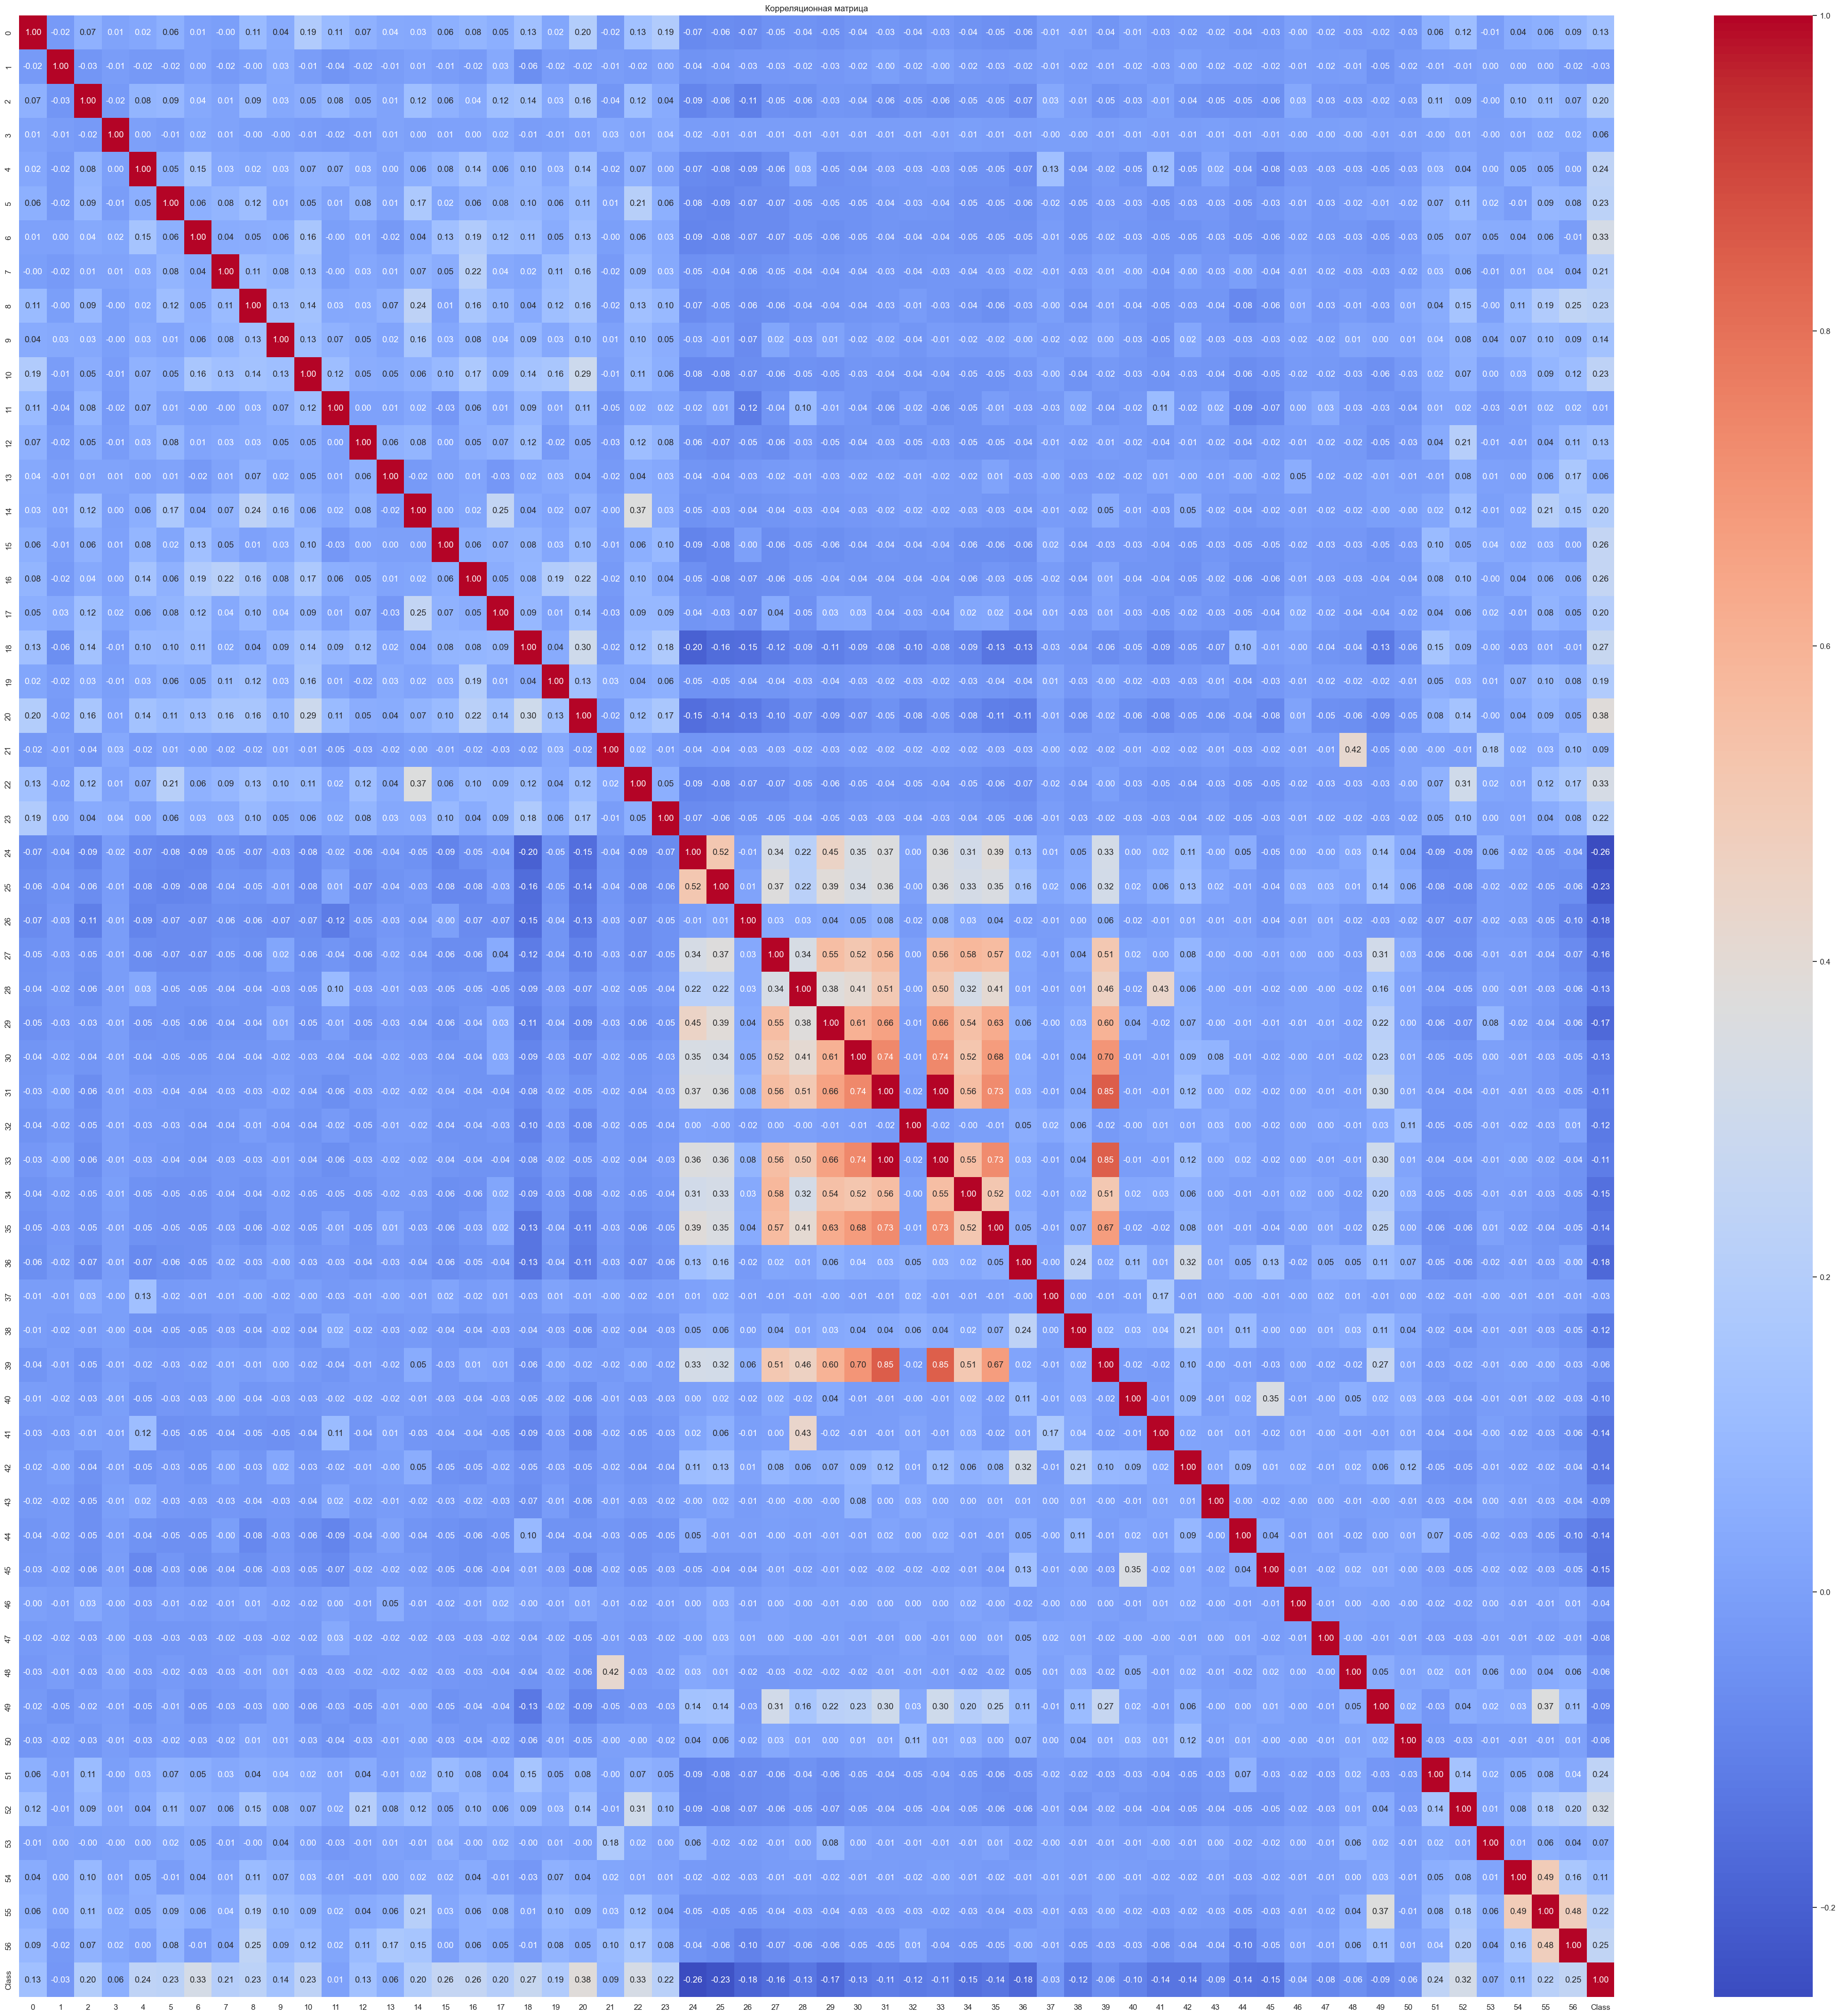

In [19]:
# 2. Многомерная визуализация: тепловая карта корреляций между признаками
plt.figure(figsize=(50, 50))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица")
plt.show()

In [21]:
corr_matrix["Class"].sort_values(ascending=False)

Class    1.000000
20       0.383234
22       0.334787
6        0.332117
52       0.323629
18       0.273651
15       0.263215
16       0.263204
56       0.249164
4        0.241920
51       0.241888
10       0.234529
5        0.232604
8        0.231551
23       0.216111
55       0.216097
7        0.206808
17       0.204208
2        0.196988
14       0.195902
19       0.189761
9        0.138962
12       0.132927
0        0.126208
54       0.109999
21       0.091860
53       0.065067
13       0.060027
3        0.057371
11       0.007741
1       -0.030224
37      -0.031035
46      -0.044679
48      -0.059630
50      -0.064709
39      -0.064801
47      -0.084020
49      -0.089672
43      -0.094594
40      -0.097375
33      -0.112754
31      -0.114214
32      -0.119931
38      -0.122831
30      -0.126912
28      -0.133523
42      -0.135664
35      -0.136134
41      -0.136615
44      -0.140408
45      -0.146138
34      -0.149225
27      -0.158800
29      -0.171095
36      -0.178045
26      -0

In [23]:
data_changed = data.drop(["33", "21", "53", "13", "3", "11", "1", "37", "46", "48", "50", "39", "47", "49", "43", "40"], axis=1, inplace=False)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Стандартизация исходного набора данных (data)
# Исключаем целевой признак 'Class'
features = data.drop("Class", axis=1).columns
data_scaled_features = scaler.fit_transform(data[features])
data_scaled = pd.DataFrame(data_scaled_features, columns=features)
data_scaled["Class"] = data["Class"].values

# Стандартизация изменённого набора данных (data_changed)
# Исключаем целевой признак 'Class'
features_changed = data_changed.drop("Class", axis=1).columns
data_changed_scaled_features = scaler.fit_transform(data_changed[features_changed])
data_changed_scaled = pd.DataFrame(data_changed_scaled_features, columns=features_changed)
data_changed_scaled["Class"] = data_changed["Class"].values

print("\nСтандартизированный исходный набор данных:")
display(data_scaled.head())

print("\nСтандартизированный изменённый набор данных:")
display(data_changed_scaled.head())


Стандартизированный исходный набор данных:


,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,Class
0,-0.342434,0.330885,0.712859,-0.0469,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,...,-0.158453,-0.514307,-0.155198,0.624007,-0.308355,-0.103048,-0.045247,0.045298,-0.008724,1
1,0.345359,0.051909,0.435130,-0.0469,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,...,-0.158453,-0.026007,-0.155198,0.126203,0.423783,0.008763,-0.002443,0.250563,1.228324,1
2,-0.145921,-0.165072,0.851723,-0.0469,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,...,-0.117376,0.014684,-0.155198,0.008496,0.440053,-0.079754,0.145921,2.221106,3.258733,1
3,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.158453,-0.007511,-0.155198,-0.161934,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222,1
4,-0.342434,-0.165072,-0.556761,-0.0469,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,...,-0.158453,-0.014910,-0.155198,-0.164387,-0.308355,-0.103048,-0.052150,-0.062466,-0.152222,1



Стандартизированный изменённый набор данных:


,0,2,4,5,6,7,8,9,10,12,...,41,42,44,45,51,52,54,55,56,Class
0,-0.342434,0.712859,0.011565,-0.350266,-0.291794,-0.262562,-0.323302,-0.371364,-0.296860,-0.312055,...,-0.1726,-0.205993,-0.297776,-0.197387,0.624007,-0.308355,-0.045247,0.045298,-0.008724,1
1,0.345359,0.435130,-0.256117,0.672399,0.244743,-0.088010,-0.323302,1.086711,0.745206,1.847391,...,-0.1726,-0.205993,-0.297776,-0.197387,0.126203,0.423783,-0.002443,0.250563,1.228324,1
2,-0.145921,0.851723,1.364846,0.343685,0.193644,0.036670,1.974017,0.016422,1.588784,0.086612,...,-0.1726,0.330230,-0.238463,-0.131527,0.008496,0.440053,0.145921,2.221106,3.258733,1
3,-0.342434,-0.556761,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,1.241428,0.717835,...,-0.1726,-0.205993,-0.297776,-0.197387,-0.161934,-0.308355,-0.052150,-0.062466,-0.152222,1
4,-0.342434,-0.556761,0.472573,-0.350266,0.500237,1.308402,0.789462,0.605857,1.241428,0.717835,...,-0.1726,-0.205993,-0.297776,-0.197387,-0.164387,-0.308355,-0.052150,-0.062466,-0.152222,1


In [33]:
# Разделение данных на обучающую, валидационную и тестовую выборки для всех наборов данных

from sklearn.model_selection import train_test_split

def split_dataset(df, target='Class', test_size=0.2, val_size=0.2, random_state=42):
    """    
    Параметры:
    - df: исходный DataFrame.
    - target: имя столбца с целевой переменной.
    - test_size: доля выборки для теста.
    - val_size: доля обучающей выборки, выделенная для валидации.
    - random_state: фиксированное значение для воспроизводимости.
    
    Возвращает:
    - train: обучающая выборка.
    - val: валидационная выборка.
    - test: тестовая выборка.
    """
    # Сначала выделяем тестовую выборку
    train_val, test = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target])
    
    # Далее из оставшейся выборки выделяем валидационную
    train, val = train_test_split(train_val, test_size=val_size, random_state=random_state, stratify=train_val[target])
    
    return train, val, test

# Разбиваем исходный набор данных
train_data, val_data, test_data = split_dataset(data, target='Class')
print("data:")
print("Обучающая выборка:", train_data.shape)
print("Валидационная выборка:", val_data.shape)
print("Тестовая выборка:", test_data.shape)

# Разбиваем стандартизированный исходный набор данных
train_data_scaled, val_data_scaled, test_data_scaled = split_dataset(data_scaled, target='Class')
print("\ndata_scaled:")
print("Обучающая выборка:", train_data_scaled.shape)
print("Валидационная выборка:", val_data_scaled.shape)
print("Тестовая выборка:", test_data_scaled.shape)

# Разбиваем измененный набор данных
train_data_changed, val_data_changed, test_data_changed = split_dataset(data_changed, target='Class')
print("\ndata_changed:")
print("Обучающая выборка:", train_data_changed.shape)
print("Валидационная выборка:", val_data_changed.shape)
print("Тестовая выборка:", test_data_changed.shape)

# Разбиваем стандартизированный измененный набор данных
train_data_changed_scaled, val_data_changed_scaled, test_data_changed_scaled = split_dataset(data_changed_scaled, target='Class')
print("\ndata_changed_scaled:")
print("Обучающая выборка:", train_data_changed_scaled.shape)
print("Валидационная выборка:", val_data_changed_scaled.shape)
print("Тестовая выборка:", test_data_changed_scaled.shape)


data:
Обучающая выборка: (2944, 58)
Валидационная выборка: (736, 58)
Тестовая выборка: (921, 58)

data_scaled:
Обучающая выборка: (2944, 58)
Валидационная выборка: (736, 58)
Тестовая выборка: (921, 58)

data_changed:
Обучающая выборка: (2944, 42)
Валидационная выборка: (736, 42)
Тестовая выборка: (921, 42)

data_changed_scaled:
Обучающая выборка: (2944, 42)
Валидационная выборка: (736, 42)
Тестовая выборка: (921, 42)


In [88]:
# Обучение и оценка моделей (пункт 5)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, Input, Reshape

def build_fully_connected_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def build_cnn_model(input_dim, filters=32, kernel_size=3, dense_units=32, dropout_rate=0.5):
    # Для применения Conv1D входные данные нужно преобразовать в форму (n_features, 1)
    model = Sequential([
        Input(shape=(input_dim,)),
        Reshape((input_dim, 1)),
        Conv1D(filters=filters, kernel_size=kernel_size, activation='relu'),
        Flatten(),
        Dense(dense_units, activation='relu'),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model



In [110]:
# Извлекаем признаки и целевую переменную из исходного набора данных
d_X_train = train_data.drop("Class", axis=1).values
d_Y_train = train_data["Class"].values

# Определяем форму входа для полносвязной модели
input_shape_fc = (d_X_train.shape[1],)

# --- Обучение полносвязной модели (FCNN) ---
d_fc_model = build_fully_connected_model(input_shape_fc)
d_fc_model.fit(d_X_train, d_Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 314us/step - accuracy: 0.4968 - loss: 8.9939 
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 300us/step - accuracy: 0.5728 - loss: 4.7575
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 311us/step - accuracy: 0.6622 - loss: 3.1139
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step - accuracy: 0.6993 - loss: 2.2788
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 306us/step - accuracy: 0.7318 - loss: 1.4966
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step - accuracy: 0.7589 - loss: 1.4519
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step - accuracy: 0.7546 - loss: 1.1069
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 296us/step - accuracy: 0.7880 - loss: 0.8234
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 289us/step - accuracy: 0.7961 - loss: 0.9060
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step - accuracy: 0.8073 - loss: 0.7904
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step - accuracy: 0.8129 - loss: 0.7137
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 

In [111]:
# --- Обучение одномерной сверточной модели (1D CNN) ---
d_cnn_model = build_cnn_model(d_X_train.shape[1])
d_cnn_model.fit(d_X_train, d_Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.6400 - loss: 1.2339
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step - accuracy: 0.8489 - loss: 0.3661
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step - accuracy: 0.8806 - loss: 0.2976
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - accuracy: 0.8849 - loss: 0.3084
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step - accuracy: 0.8919 - loss: 0.2703
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 749us/step - accuracy: 0.8725 - loss: 0.2915
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step - accuracy: 0.8829 - loss: 0.2764
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 725us/step - accuracy: 0.9031 - loss: 0.2669
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 714us/step - accuracy: 0.8955 - loss: 0.2674
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 706us/step - accuracy: 0.9013 - loss: 0.2490
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - accuracy: 0.9069 - loss: 0.2407
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0

In [114]:
# Извлекаем признаки и целевую переменную из стандартизированного исходного набора данных
sd_X_train = train_data_scaled.drop("Class", axis=1).values
sd_Y_train = train_data_scaled["Class"].values

# Определяем форму входа для полносвязной модели
input_shape_fc = (sd_X_train.shape[1],)

# --- Обучение полносвязной модели (FCNN) ---
sd_fc_model = build_fully_connected_model(input_shape_fc)
sd_fc_model.fit(sd_X_train, sd_Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - accuracy: 0.7142 - loss: 0.5743
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 289us/step - accuracy: 0.8829 - loss: 0.3336
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step - accuracy: 0.8944 - loss: 0.2822
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step - accuracy: 0.9176 - loss: 0.2300
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 307us/step - accuracy: 0.9200 - loss: 0.2217
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 299us/step - accuracy: 0.9209 - loss: 0.2065
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step - accuracy: 0.9251 - loss: 0.2020
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step - accuracy: 0.9347 - loss: 0.2011
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step - accuracy: 0.9333 - loss: 0.1995
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step - accuracy: 0.9304 - loss: 0.1880
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step - accuracy: 0.9368 - loss: 0.1765
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0

In [116]:
# --- Обучение одномерной сверточной модели (1D CNN) ---
sd_cnn_model = build_cnn_model(sd_X_train.shape[1])
sd_cnn_model.fit(sd_X_train, sd_Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 657us/step - accuracy: 0.8250 - loss: 0.4202
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - accuracy: 0.9305 - loss: 0.2161
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - accuracy: 0.9240 - loss: 0.2142
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step - accuracy: 0.9345 - loss: 0.1742
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step - accuracy: 0.9346 - loss: 0.1896
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 731us/step - accuracy: 0.9318 - loss: 0.1832
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 700us/step - accuracy: 0.9431 - loss: 0.1674
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step - accuracy: 0.9436 - loss: 0.1683
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 729us/step - accuracy: 0.9440 - loss: 0.1609
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 756us/step - accuracy: 0.9412 - loss: 0.1722
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - accuracy: 0.9442 - loss: 0.1468
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0

In [117]:
# Извлекаем признаки и целевую переменную из изменённого набора данных
dc_X_train = train_data_changed.drop("Class", axis=1).values
dc_Y_train = train_data_changed["Class"].values

# Определяем форму входа для полносвязной модели
input_shape_fc = (dc_X_train.shape[1],)

# --- Обучение полносвязной модели (FCNN) ---
dc_fc_model = build_fully_connected_model(input_shape_fc)
dc_fc_model.fit(dc_X_train, dc_Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 323us/step - accuracy: 0.5094 - loss: 7.5075 
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 289us/step - accuracy: 0.5653 - loss: 4.0813
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step - accuracy: 0.6660 - loss: 2.6051
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 310us/step - accuracy: 0.7013 - loss: 2.4252
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 300us/step - accuracy: 0.7058 - loss: 1.8833
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step - accuracy: 0.7326 - loss: 1.3615
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step - accuracy: 0.7528 - loss: 1.3127
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 292us/step - accuracy: 0.7490 - loss: 1.2312
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 308us/step - accuracy: 0.7716 - loss: 0.8537
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step - accuracy: 0.7795 - loss: 0.8448
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 289us/step - accuracy: 0.7826 - loss: 0.7120
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 

In [120]:
# --- Обучение одномерной сверточной модели (1D CNN) ---
dc_cnn_model = build_cnn_model(dc_X_train.shape[1])
dc_cnn_model.fit(dc_X_train, dc_Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 545us/step - accuracy: 0.6524 - loss: 1.2132
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - accuracy: 0.8114 - loss: 0.4458
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - accuracy: 0.8414 - loss: 0.3654
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - accuracy: 0.8733 - loss: 0.3263
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step - accuracy: 0.8697 - loss: 0.3165
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 572us/step - accuracy: 0.8677 - loss: 0.3188
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - accuracy: 0.8856 - loss: 0.2897
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step - accuracy: 0.8919 - loss: 0.2719
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 591us/step - accuracy: 0.8736 - loss: 0.3013
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - accuracy: 0.9040 - loss: 0.2697
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - accuracy: 0.8945 - loss: 0.2678
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0

In [121]:
# Извлекаем признаки и целевую переменную из стандартизированного изменённого набора данных
sdc_X_train = train_data_changed_scaled.drop("Class", axis=1).values
sdc_Y_train = train_data_changed_scaled["Class"].values

# Определяем форму входа для полносвязной модели
input_shape_fc = (sdc_X_train.shape[1],)

# --- Обучение полносвязной модели (FCNN) ---
sdc_fc_model = build_fully_connected_model(input_shape_fc)
sdc_fc_model.fit(sdc_X_train, sdc_Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step - accuracy: 0.7122 - loss: 0.6004
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 276us/step - accuracy: 0.8695 - loss: 0.3399
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step - accuracy: 0.8937 - loss: 0.2821
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step - accuracy: 0.9062 - loss: 0.2524
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 301us/step - accuracy: 0.9129 - loss: 0.2412
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 293us/step - accuracy: 0.9260 - loss: 0.2171
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step - accuracy: 0.9167 - loss: 0.2087
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step - accuracy: 0.9224 - loss: 0.2036
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 290us/step - accuracy: 0.9301 - loss: 0.2017
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 298us/step - accuracy: 0.9131 - loss: 0.2345
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 284us/step - accuracy: 0.9174 - loss: 0.2197
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0

In [124]:
# --- Обучение одномерной сверточной модели (1D CNN) ---
sdc_cnn_model = build_cnn_model(sdc_X_train.shape[1])
sdc_cnn_model.fit(sdc_X_train, sdc_Y_train, epochs=100, batch_size=32, verbose=1)

Epoch 1/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - accuracy: 0.8414 - loss: 0.4198
Epoch 2/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - accuracy: 0.9280 - loss: 0.2309
Epoch 3/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - accuracy: 0.9167 - loss: 0.2353
Epoch 4/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step - accuracy: 0.9259 - loss: 0.2089
Epoch 5/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - accuracy: 0.9329 - loss: 0.1859
Epoch 6/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - accuracy: 0.9387 - loss: 0.1779
Epoch 7/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.9364 - loss: 0.1820
Epoch 8/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - accuracy: 0.9443 - loss: 0.1634
Epoch 9/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 642us/step - accuracy: 0.9398 - loss: 0.1761
Epoch 10/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 634us/step - accuracy: 0.9389 - loss: 0.1592
Epoch 11/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 620us/step - accuracy: 0.9414 - loss: 0.1647
Epoch 12/100
92/92 ━━━━━━━━━━━━━━━━━━━━ 0

In [125]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

def compare_classification_model(model, x_train, x_val, y_train, y_val):
    # Получаем предсказания (порог 0.5)
    y_train_pred = (model.predict(x_train) > 0.5).astype('int64')
    y_val_pred = (model.predict(x_val) > 0.5).astype('int64')

    # Вычисляем метрики для обучающей выборки
    accuracy_train = accuracy_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    
    # Вычисляем метрики для валидационной выборки
    accuracy_val = accuracy_score(y_val, y_val_pred)
    f1_val = f1_score(y_val, y_val_pred)

    # Выводим результаты
    print(f'Accuracy for train: {accuracy_train}')
    print(f'F1 Score for train: {f1_train}')
    print(f'Accuracy for validation: {accuracy_val}')
    print(f'F1 Score for validation: {f1_val}')
    print('--------------------------------------')


# Для каждого набора данных извлекаем признаки и целевую переменную из обучающих и валидационных выборок:

# 1. Исходный набор (d)
d_X_train = train_data.drop("Class", axis=1).values
d_Y_train = train_data["Class"].values
d_X_val   = val_data.drop("Class", axis=1).values
d_Y_val   = val_data["Class"].values

# 2. Стандартизированный исходный набор (sd)
sd_X_train = train_data_scaled.drop("Class", axis=1).values
sd_Y_train = train_data_scaled["Class"].values
sd_X_val   = val_data_scaled.drop("Class", axis=1).values
sd_Y_val   = val_data_scaled["Class"].values

# 3. Изменённый набор (dc)
dc_X_train = train_data_changed.drop("Class", axis=1).values
dc_Y_train = train_data_changed["Class"].values
dc_X_val   = val_data_changed.drop("Class", axis=1).values
dc_Y_val   = val_data_changed["Class"].values

# 4. Стандартизированный изменённый набор (sdc)
sdc_X_train = train_data_changed_scaled.drop("Class", axis=1).values
sdc_Y_train = train_data_changed_scaled["Class"].values
sdc_X_val   = val_data_changed_scaled.drop("Class", axis=1).values
sdc_Y_val   = val_data_changed_scaled["Class"].values

# Сравниваем результаты моделей:
print("----- FCNN на d -----")
compare_classification_model(d_fc_model, d_X_train, d_X_val, d_Y_train, d_Y_val)

print("----- CNN на d -----")
compare_classification_model(d_cnn_model, d_X_train, d_X_val, d_Y_train, d_Y_val)

print("----- FCNN на sd -----")
compare_classification_model(sd_fc_model, sd_X_train, sd_X_val, sd_Y_train, sd_Y_val)

print("----- CNN на sd -----")
compare_classification_model(sd_cnn_model, sd_X_train, sd_X_val, sd_Y_train, sd_Y_val)

print("----- FCNN на dc -----")
compare_classification_model(dc_fc_model, dc_X_train, dc_X_val, dc_Y_train, dc_Y_val)

print("----- CNN на dc -----")
compare_classification_model(dc_cnn_model, dc_X_train, dc_X_val, dc_Y_train, dc_Y_val)

print("----- FCNN на sdc -----")
compare_classification_model(sdc_fc_model, sdc_X_train, sdc_X_val, sdc_Y_train, sdc_Y_val)

print("----- CNN на sdc -----")
compare_classification_model(sdc_cnn_model, sdc_X_train, sdc_X_val, sdc_Y_train, sdc_Y_val)


----- FCNN на d -----
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 229us/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 234us/step
Accuracy for train: 0.953125
F1 Score for train: 0.9397379912663756
Accuracy for validation: 0.9538043478260869
F1 Score for validation: 0.9405594405594405
--------------------------------------
----- CNN на d -----
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 374us/step
Accuracy for train: 0.9633152173913043
F1 Score for train: 0.9530434782608695
Accuracy for validation: 0.9538043478260869
F1 Score for validation: 0.9407665505226481
--------------------------------------
----- FCNN на sd -----
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 214us/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 257us/step
Accuracy for train: 0.9836956521739131
F1 Score for train: 0.9792207792207792
Accuracy for validation: 0.9538043478260869
F1 Score for validation: 0.9405594405594405
--------------------------------------
----- CNN на sd -----
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step
23/23 ━━━━━━━━━━━━━━

In [128]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Извлекаем признаки и целевую переменную из тестового набора для стандартизированного исходного набора (sd)
sd_X_test = test_data_scaled.drop("Class", axis=1).values
sd_Y_test = test_data_scaled["Class"].values

# Делаем предсказания с помощью лучшей модели (CNN на sd, т.е. sd_cnn_model)
sd_Y_test_pred = (sd_cnn_model.predict(sd_X_test) > 0.5).astype('int64')

# Вычисляем метрики на тестовом наборе
accuracy_test = accuracy_score(sd_Y_test, sd_Y_test_pred)
balanced_accuracy_test = balanced_accuracy_score(sd_Y_test, sd_Y_test_pred)
f1_test = f1_score(sd_Y_test, sd_Y_test_pred)

print("Test metrics for best model (CNN on sd):")
print(f"Accuracy: {accuracy_test}")
print(f"Balanced Accuracy: {balanced_accuracy_test}")
print(f"F1 Score: {f1_test}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Test metrics for best model (CNN on sd):
Accuracy: 0.9446254071661238
Balanced Accuracy: 0.9408231878906366
F1 Score: 0.9292649098474342


In [140]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# Оборачиваем функцию создания модели, используя вашу функцию build_cnn_model.
model = KerasClassifier(
    model=build_cnn_model,  # используем вашу функцию, которая принимает input_dim, filters, kernel_size, dense_units, dropout_rate
    verbose=0  # отключаем подробный вывод
)

# Определяем пространство гиперпараметров.
param_grid = {
    'model__filters': [32, 64],
    'model__kernel_size': [3, 5],
    'model__dense_units': [16, 32, 64],
    'model__dropout_rate': [0.3, 0.5],
    'batch_size': [16, 32],
    'epochs': [100],
    'model__input_dim': [sd_X_train.shape[1]]  # Передаем размерность входных данных
}

# Объединяем обучающие и валидационные данные для проведения Grid Search.
X_combined = np.concatenate((sd_X_train, sd_X_val), axis=0)
Y_combined = np.concatenate((sd_Y_train, sd_Y_val), axis=0)

# Инициализируем GridSearchCV с 3-кратной кросс-валидацией и метрикой accuracy.
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1)

# Запуск подбора гиперпараметров.
grid_result = grid.fit(X_combined, Y_combined)

# Вывод лучших гиперпараметров и достигнутой точности.
print(f"Лучшие параметры: {grid_result.best_params_}")
print(f"Лучший результат (accuracy): {grid_result.best_score_}")


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Лучшие параметры: {'batch_size': 32, 'epochs': 100, 'model__dense_units': 64, 'model__dropout_rate': 0.3, 'model__filters': 32, 'model__input_dim': 57, 'model__kernel_size': 3}
Лучший результат (accuracy): 0.9483683019322804


In [142]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Используем лучшую модель из Grid Search для предсказаний на тестовом наборе sd
sd_Y_test_pred_grid = (grid_result.best_estimator_.predict(sd_X_test) > 0.5).astype('int64')

# Вычисляем метрики на тестовом наборе для модели из Grid Search
accuracy_grid = accuracy_score(sd_Y_test, sd_Y_test_pred_grid)
balanced_accuracy_grid = balanced_accuracy_score(sd_Y_test, sd_Y_test_pred_grid)
f1_grid = f1_score(sd_Y_test, sd_Y_test_pred_grid)

print("Test metrics for best Grid Search model (CNN on sd):")
print(f"Accuracy: {accuracy_grid}")
print(f"Balanced Accuracy: {balanced_accuracy_grid}")
print(f"F1 Score: {f1_grid}")

Test metrics for best Grid Search model (CNN on sd):
Accuracy: 0.9457111834961998
Balanced Accuracy: 0.9417192452383067
F1 Score: 0.9305555555555556
